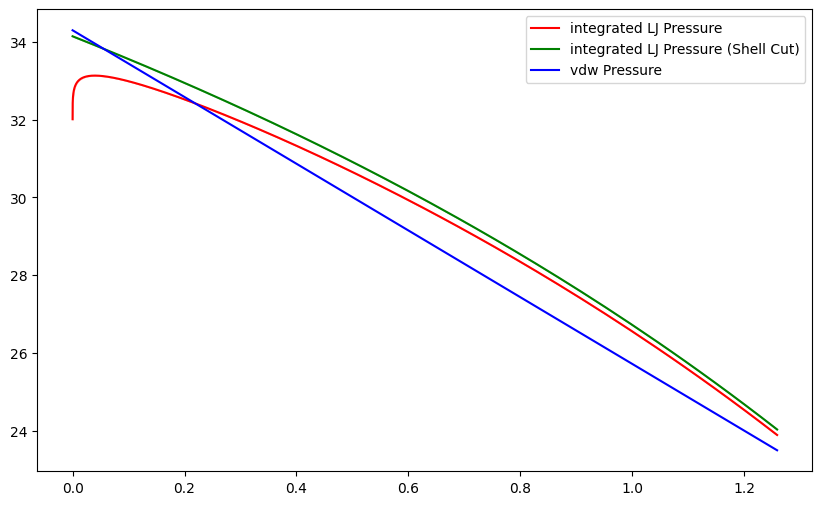

In [178]:
import numpy as np
from scipy.integrate import quad
from scipy.constants import Boltzmann as kB
import matplotlib.pyplot as plt

def lennard_jones(r, epsilon, sigma):
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def integrand(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj(T, epsilon, sigma, n):
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error


def lennard_jones_cut(r, epsilon, sigma):
    if r > sigma:
        return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)
    else:
        return np.inf

def integrand_cut(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones_cut(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj_cut(T, epsilon, sigma, n):
    # r_min = 0.001 * sigma
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand_cut, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error / 3

def vdw(T, epsilon, sigma, n):
    return n * T / (1 - 2 * n * np.pi * sigma ** 3 / 3) - 2 * np.pi * sigma**3 * 4 * epsilon * n**2 / 3

epsilons = np.logspace(-10, 0.1, 1000)
sigma = 0.1
T = 1

pressures_lj = []
pressures_lj_err = []
pressures_lj_cut = []
pressures_lj_cut_err = []
pressures_vdw = []

for eps in epsilons:
    p, err = pressure_lj(T, eps, sigma, 32)
    pressures_lj.append(p)
    pressures_lj_err.append(err)
    p, err = pressure_lj_cut(T, eps, sigma, 32)
    pressures_lj_cut.append(p)
    pressures_lj_cut_err.append(err)
    pressures_vdw.append(vdw(T, eps, sigma, 32))
plt.figure(figsize=(10, 6))
plt.plot(epsilons, pressures_lj, label='integrated LJ Pressure', c='r')
plt.plot(epsilons, pressures_lj_cut, label='integrated LJ Pressure (Shell Cut)', c='g')
plt.plot(epsilons, pressures_vdw, label='vdw Pressure', c='b')
plt.fill_between(epsilons, np.array(pressures_lj) - np.array(pressures_lj_err), np.array(pressures_lj) + np.array(pressures_lj_err), alpha=0.2, color='r')
plt.fill_between(epsilons, np.array(pressures_lj_cut) - np.array(pressures_lj_cut_err), np.array(pressures_lj_cut) + np.array(pressures_lj_cut_err), alpha=0.2, color='g')
plt.legend()

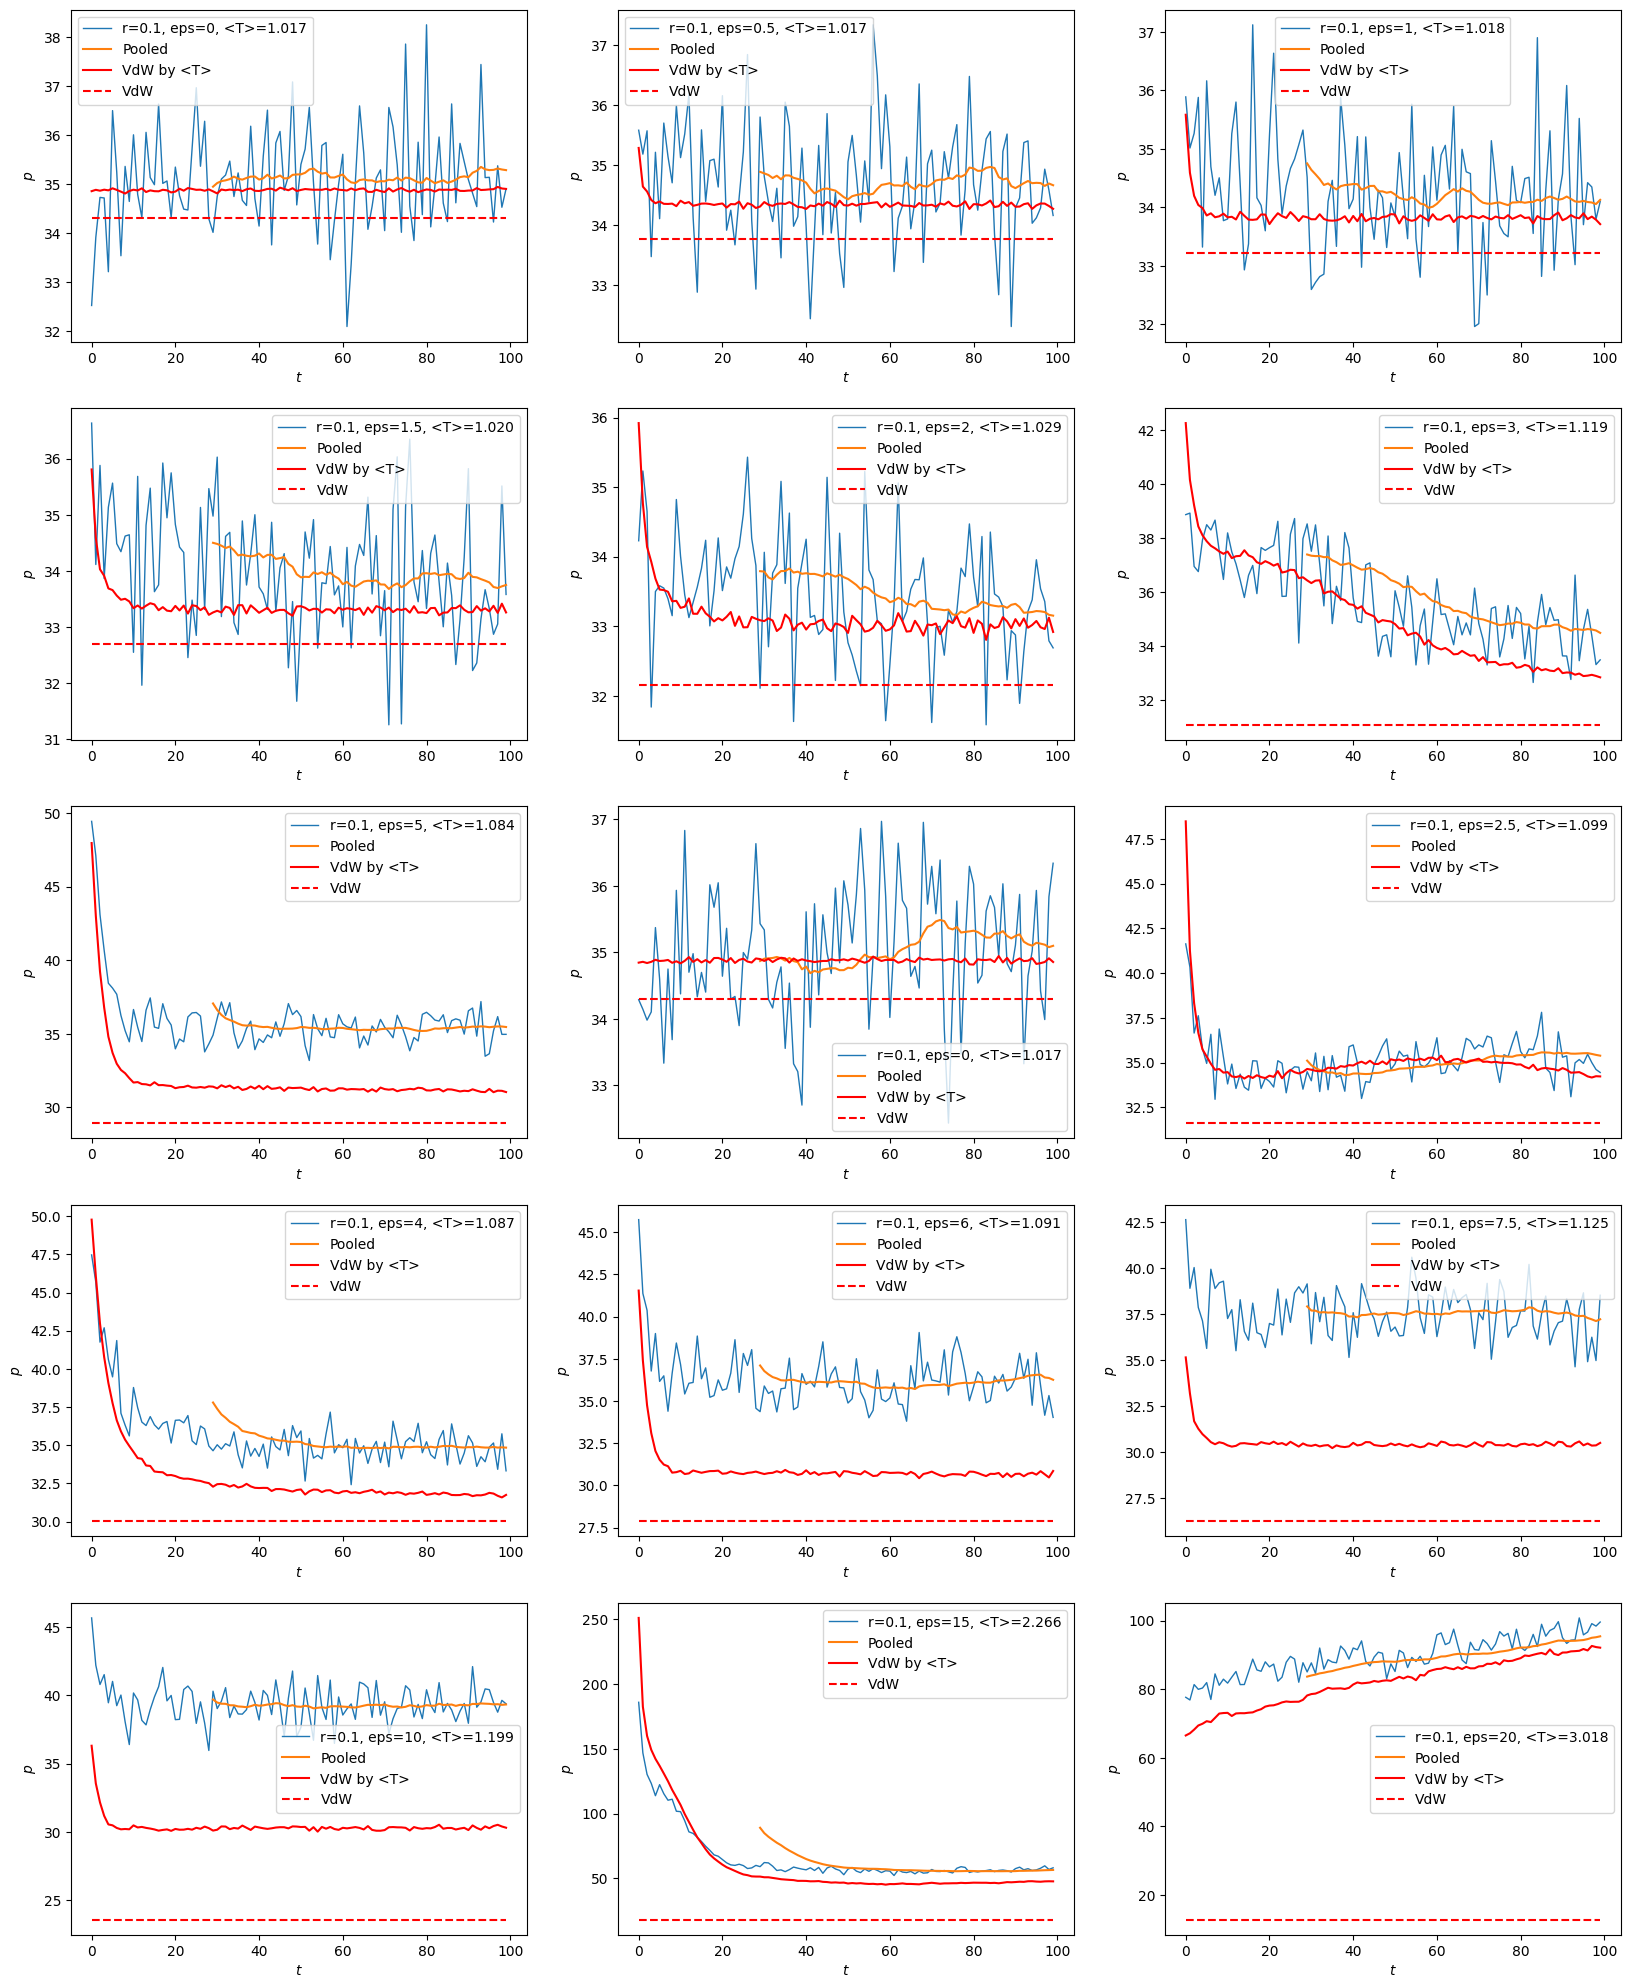

In [179]:
import numpy as np
import matplotlib.pyplot as plt
import os
def rho(n, r):
    return 4 * n * np.pi * r**3 / 3

def pressure_vdw(r, n, T, l_j_epsilon):
    return n * T / (1 - 2 * n * np.pi * r ** 3 / 3) - 2 * np.pi * r**3 * 4 * l_j_epsilon * n**2 / 3

def pressure_vdw_test(r, n, T, l_j_epsilon):
    return n * T / (1 - 2 * n * np.pi * r ** 3 / 3) - 1 * np.pi * r**3 * 4 * l_j_epsilon * n**2 / 12

pressures = []
rs = []
energies = []
eps = [0, 0.5, 1, 1.5, 2, 3, 5, 0, 2.5, 4, 6, 7.5, 10, 15, 20]
dirs = []

for d in os.listdir('.'):
    if os.path.isdir(d) and '20250902_194900' <= d[:15] <= '20250902_213700':
        dirs.append(d)
        r = float(d.split('r')[-1])
        rs.append(r)
        fs = os.listdir(os.path.join('.', d))
        assert "config.json" in fs and "pressure.npy" in fs, f"Missing files in {d}"
        pressures.append(np.load(os.path.join('.', d, "pressure.npy")))
        energies.append(np.load(os.path.join('.', d, "mean_v2.npy")) * 200 / 3)
assert len(pressures) == len(rs) == len(energies) == len(eps)
assert sorted(dirs) == dirs
Ts = [e[-100:].mean() for e in energies]
timeList = np.arange(100)
fig, axs = plt.subplots(5, 3, figsize=(20, 25))
for i in range(len(pressures)):
    ax = axs[i // 3, i % 3]
    ax.plot(timeList, pressures[i], label=f"r={rs[i]}, eps={eps[i]}, <T>={Ts[i]:.3f}", linewidth=1)
    w = 30
    ax.plot(timeList[w-1:], np.convolve(pressures[i], np.ones(w), "valid") / w, label='Pooled')
    ax.plot(timeList, pressure_vdw_test(0.1, 32, energies[i], eps[i]), label='VdW by <T>', color='r')
    ax.plot(timeList, pressure_vdw_test(0.1, 32, np.ones_like(timeList), eps[i]), '--', label='VdW', color='r')
    # ax.plot(timeList, pressure_vdw(0.1, 32, np.ones_like(timeList), eps[i]), '--', label='VdW', color='grey')
    ax.legend()
    ax.set_xlabel("$t$")
    ax.set_ylabel("$p$")

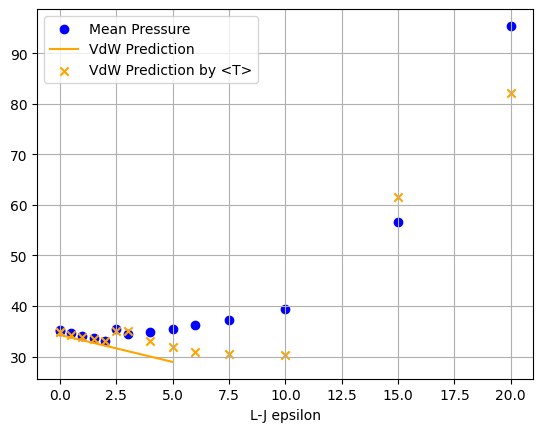

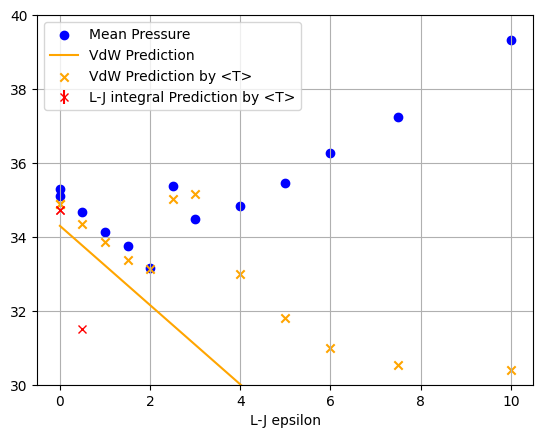

In [180]:
pressures_lj = []
pressures_lj_err = []
pressures_lj_cut = []
pressures_lj_cut_err = []
for ε, T in zip(eps, Ts):
    p, err = pressure_lj(T, ε, sigma, 32)
    pressures_lj.append(p)
    pressures_lj_err.append(err)
    p, err = pressure_lj_cut(T, ε, sigma, 32)
    pressures_lj_cut.append(p)
    pressures_lj_cut_err.append(err)
plt.scatter(eps, [p[-30:].mean() for p in pressures], label='Mean Pressure', color='blue')
plt.plot(np.linspace(0, 5, 100), pressure_vdw_test(0.1, 32, 1, np.linspace(0, 5, 100)), label='VdW Prediction', color='orange')
plt.scatter(np.array(eps), pressure_vdw_test(0.1, 32, np.array(Ts), np.array(eps)), label='VdW Prediction by <T>', marker='x', color='orange')
# plt.scatter(np.array(eps), np.array(pressures_lj_cut), label='L-J integral Prediction by <T>', marker='x', color='red')
plt.legend()
plt.grid()
plt.xlabel("L-J epsilon")
plt.show()
plt.scatter(eps, [p[-30:].mean() for p in pressures], label='Mean Pressure', color='blue')
plt.plot(np.linspace(0, 5, 100), pressure_vdw_test(0.1, 32, 1, np.linspace(0, 5, 100)), label='VdW Prediction', color='orange')
plt.scatter(np.array(eps), pressure_vdw_test(0.1, 32, np.array(Ts), np.array(eps)), label='VdW Prediction by <T>', marker='x', color='orange')
# plt.scatter(np.array(eps[:-2]), np.array(pressures_lj_cut[:-2]), label='L-J integral Prediction by <T>', marker='x', color='red')
plt.errorbar(np.array(eps), np.array(pressures_lj_cut), yerr=np.array(pressures_lj_cut_err), fmt='x', color='red', label='L-J integral Prediction by <T>')
plt.legend()
plt.grid()
plt.xlabel("L-J epsilon")
plt.xlim(-0.5,10.5)
plt.ylim(30,40)
plt.show()

In [181]:
pressure_vdw(0.1, 32, 1, 3)

8.56279542339346

In [182]:
# check if sorted
sorted(dirs) == dirs, dirs

(True,
 ['20250902_194937_931315_246r0.1',
  '20250902_195216_188459_022r0.1',
  '20250902_195419_594150_252r0.1',
  '20250902_195623_183593_061r0.1',
  '20250902_195826_166896_916r0.1',
  '20250902_200020_115032_054r0.1',
  '20250902_200220_823018_824r0.1',
  '20250902_204825_565360_629r0.1',
  '20250902_205052_220499_892r0.1',
  '20250902_205248_985953_764r0.1',
  '20250902_205448_493624_306r0.1',
  '20250902_205648_129831_875r0.1',
  '20250902_205847_511715_074r0.1',
  '20250902_213426_700409_314r0.1',
  '20250902_213624_691735_370r0.1'])

In [183]:
from pdf2image import convert_from_path
for i in range(len(dirs)):
    if not os.path.exists(os.path.join('.', 'EPS' + str(eps[i]) + 'points.png')):
        pages = convert_from_path(os.path.join('.', dirs[i], 'points.pdf'), 300)
        assert len(pages) == 1
        pages[0].save(os.path.join('.', 'EPS' + str(eps[i]) + 'points.png'), 'PNG')

In [184]:
rho(32, 0.1), rho(32, 0.05)

(0.13404128655316452, 0.016755160819145565)